# Анализ данных и обучение модели для предсказания целевой переменной `SI`

In [4]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from scipy.stats import burr, fisk, genextreme, shapiro, weibull_min
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings('ignore')

In [5]:
pd.set_option('display.max_columns', None)

# 1. Загрузка и подготовка данных

## Загрузка датасета

In [6]:
train = pd.read_csv('train.csv', sep=',')

In [7]:
train.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1.789178e+03,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,11.761885,18.199101,12.132734,11.440240,12.483670,4.736863,17.449271,0.0,0.000000,0.000000,0.000000,29.867250,30.331835,0,0.000000,4.899910,5.687386,0.000000,11.761885,24.967341,4.736863,0.000000,0.000000,30.331835,0.000000,0.000000,0,12.47,0.000000,0.000000,0.0,0.000000,0.000000,24.967341,5.687386,0.000000,17.828252,29.165378,4.736863,5.466584,1.919608,2.247685,0.000000,1.247130,2.132289,10.398397,0.000000,1.588307,0.000000,0.400000,13,0,2,0,1,1,1,0,1,3,0,3,1,0,1,1,2,2.1714,57.0650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.46

In [9]:
train.shape

(751, 214)

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


Переименуем целевые колонки, чтобы дальше работать с короткими названиями:

In [11]:
train.rename(
    columns={
        'IC50, mM': 'IC50',
        'CC50, mM': 'CC50'
    },
    inplace=True
)

Удалим колонку `index`, потому что это технический идентификатор объекта

In [12]:
train = train.drop('index', axis=1)

## Пропуски

In [13]:
absences = train.isna().sum().sum()
absences_perc = absences / train.size * 100

print(f"Количество пропусков: {absences} ({absences_perc:.4f}%)")

Количество пропусков: 24 (0.0150%)


Удалим полностью пустые строки, если они есть:

In [14]:
train.dropna(how='all', inplace=True)

In [15]:
absences = train.isna().sum().sum()
absences_perc = absences / train.size * 100

print(f"Количество пропусков после удаления пустых строк: {absences} ({absences_perc:.4f}%)")

Количество пропусков после удаления пустых строк: 24 (0.0150%)


Перед обучением оставим только полностью заполненные строки, как было в исходном ноутбуке:

In [16]:
train_clean = train.dropna()

In [17]:
train_clean.shape

(749, 213)

## Заключение

В исходном датасете 751 строка. После удаления технической колонки `index` остается 213 колонок: 3 целевые переменные (`IC50`, `CC50`, `SI`) и 210 признаков.

В данных есть 24 пропуска. После удаления строк с пропусками для обучения остается 749 строк. Так как пропусков мало, такой способ очистки не должен сильно уменьшить выборку.

Дальше анализируем `SI`, потому что именно эта переменная будет предсказываться. Для нее важно отдельно проверить форму распределения и выбросы: по описательной статистике уже видно, что значения `SI` могут сильно отличаться по масштабу.

# 2. Анализ данных

## Параметры датасета

Список колонок:

In [18]:
train.columns

Index(['IC50', 'CC50', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex',
       'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=213)

Описание данных:

In [19]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 213 entries, IC50 to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.2 MB


In [20]:
train.describe()

,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,749.000000,749.000000,749.000000,749.000000,751.000000,751.000000,751.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,751.000000,7.510000e+02,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,7.510000e+02,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.

## Анализ целевой переменной

In [21]:
TARGET = 'SI'

### Распределение

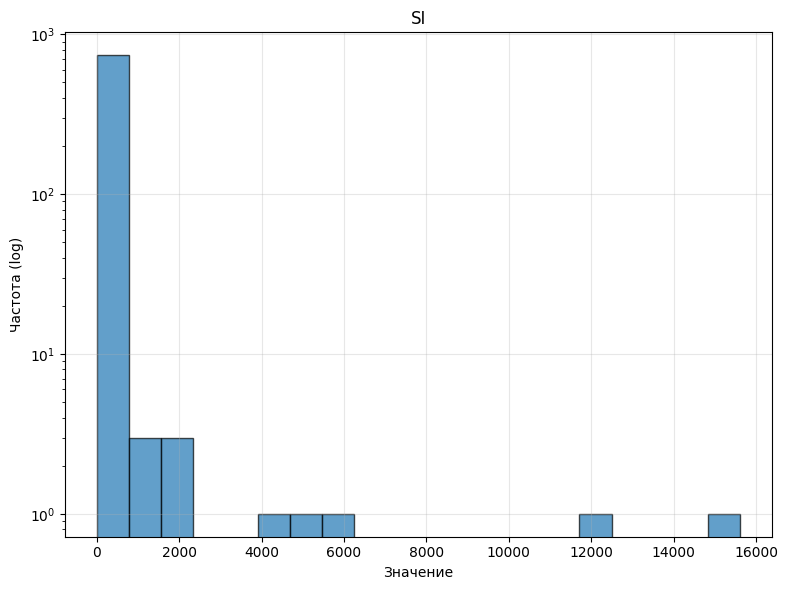

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
data = train[TARGET].dropna()

ax.hist(
    data,
    bins=20,
    alpha=0.7,
    edgecolor='black'
)
ax.set_title(TARGET, fontsize=12)
ax.set_xlabel('Значение', fontsize=10)
ax.set_ylabel('Частота (log)', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

* Распределение `SI` резко скошено вправо: среднее значение (`89.29`) намного больше медианы (`4.00`). Значит среднее плохо описывает типичный объект, потому что его сильно увеличивают редкие большие значения.
* Основная часть объектов имеет небольшие значения `SI`: верхний квартиль равен `17.12`. При этом максимум достигает `15620.60`, то есть в данных есть очень длинный правый хвост.
* Из этого следует, что RMSE будет особенно чувствителен к ошибкам на редких больших значениях `SI`. Поэтому дальше нужно отдельно проверить выбросы и не делать вывод о качестве модели только по среднему значению целевой переменной.

### Анализ выбросов

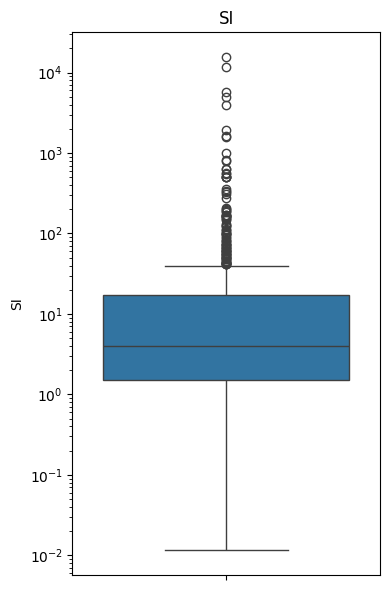

In [23]:
fig, ax = plt.subplots(figsize=(4, 6))

sns.boxplot(
    y=train[TARGET],
    ax=ax
)
ax.set_title(TARGET)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

Boxplot подтверждает, что у `SI` есть много значений выше основной массы наблюдений. Логарифмическая шкала используется только для визуализации: без нее большая часть объектов была бы сжата около нуля из-за экстремально больших значений.

Из этого следует, что выбросы нужно оценить количественно через IQR. Это позволит понять, какая доля объектов лежит за пределами типичного диапазона.

#### Границы выбросов по IQR

In [24]:
data_positive = train_clean[TARGET]
data_positive = data_positive[data_positive > 0]

Q1 = data_positive.quantile(0.25)
Q3 = data_positive.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1:.4f}")
print(f"Q3={Q3:.4f}")
print(f"Нижняя граница нормальных значений: {lower_bound:.4f}")
print(f"Верхняя граница нормальных значений: {upper_bound:.4f}")

Q1=1.5000
Q3=17.1233
Нижняя граница нормальных значений: -21.9349
Верхняя граница нормальных значений: 40.5582


In [25]:
outlier_mask = (train_clean[TARGET] < lower_bound) | (train_clean[TARGET] > upper_bound)
outliers_count = outlier_mask.sum()
outliers_perc = outliers_count / len(train_clean) * 100

print(f"Количество выбросов по IQR: {outliers_count} ({outliers_perc:.2f}%)")

Количество выбросов по IQR: 90 (12.02%)


По правилу IQR верхняя граница типичных значений `SI` равна `40.56`, а нижняя граница получилась отрицательной (`-21.93`). Так как `SI` положительная величина, выбросы появляются именно справа - среди больших значений.

Всего найдено 90 выбросов, то есть `12.02%` очищенной выборки. Это уже заметная доля данных, поэтому просто удалять их нельзя: большие значения `SI` могут быть важной частью задачи. Но при обучении и оценке качества нужно учитывать, что именно эти объекты могут давать большой вклад в RMSE.

### Распределение Вейбулла

Проверим, насколько положительные значения `SI` можно приблизить распределением Вейбулла.

In [26]:
shape_weibull, loc_weibull, scale_weibull = weibull_min.fit(data_positive, floc=0)

print(f"k={shape_weibull:.4f}")
print(f"loc={loc_weibull:.4f}")
print(f"λ={scale_weibull:.4f}")

k=0.4543
loc=0.0000
λ=14.6418


#### Теоретическая кривая

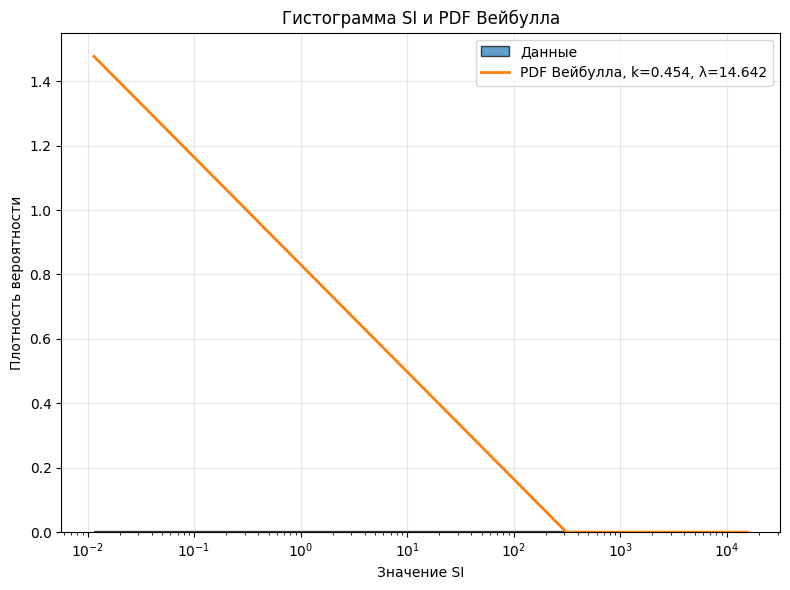

In [27]:
plt.figure(figsize=(8, 6))

count, bins, ignored = plt.hist(
    data_positive,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor='black',
    label='Данные'
)

pdf_weibull = weibull_min.pdf(
    bins,
    shape_weibull,
    loc=loc_weibull,
    scale=scale_weibull
)

plt.plot(
    bins,
    pdf_weibull,
    linewidth=2,
    label=f'PDF Вейбулла, k={shape_weibull:.3f}, λ={scale_weibull:.3f}'
)

plt.xlabel('Значение SI')
plt.ylabel('Плотность вероятности')
plt.title('Гистограмма SI и PDF Вейбулла')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

Для распределения Вейбулла получены параметры `k = 0.4543` и `λ = 14.6418`. Значение `k < 1` соответствует распределению с высокой плотностью около малых значений и длинным правым хвостом. Это похоже на общую форму `SI`, где большинство значений небольшие, а редкие значения очень крупные.

Но визуально теоретическая кривая не полностью повторяет данные: хвост распределения `SI` слишком тяжелый. Поэтому Вейбулл можно рассматривать только как приближение, а не как точное описание целевой переменной.

#### Q-Q график

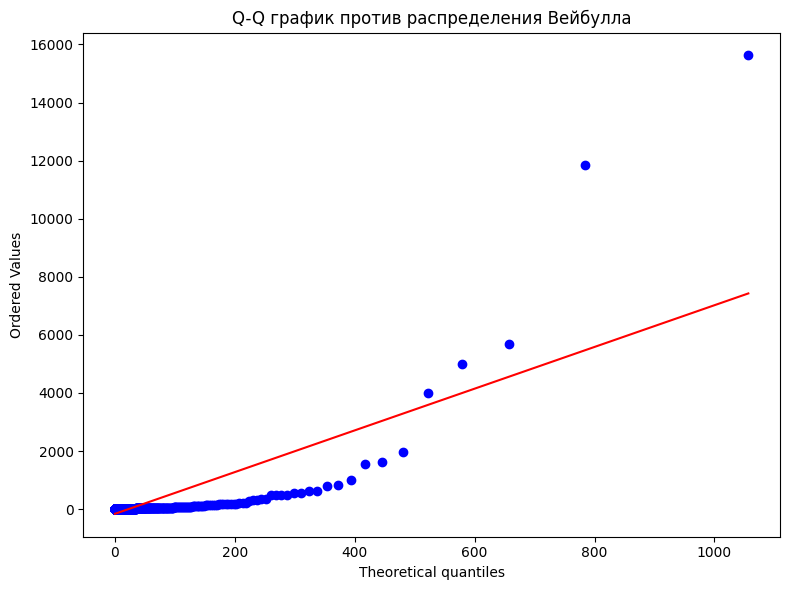

In [28]:
plt.figure(figsize=(8, 6))

weibull_dist = weibull_min(shape_weibull, loc=loc_weibull, scale=scale_weibull)
stats.probplot(
    data_positive,
    dist=weibull_dist,
    plot=plt
)
plt.title('Q-Q график против распределения Вейбулла')

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

На Q-Q графике точки заметно отходят от прямой, особенно в правой части распределения. Это означает, что распределение Вейбулла не описывает большие значения `SI`, хотя частично отражает общую правостороннюю асимметрию.

Из этого следует, что перед обучением модели нельзя опираться на предположение, что `SI` хорошо описывается распределением Вейбулла. Нужна формальная проверка через критерий Колмогорова-Смирнова.

#### Тест Колмогорова-Смирнова

In [29]:
ks_stat_weibull, ks_pvalue_weibull = stats.kstest(
    data_positive,
    lambda x: weibull_min.cdf(
        x,
        shape_weibull,
        loc=loc_weibull,
        scale=scale_weibull
    )
)

print(f"Статистика: {ks_stat_weibull:.4f}")
print(f"p-значение: {ks_pvalue_weibull:.4f}")

Статистика: 0.2017
p-значение: 0.0000


Для интерпретации теста используется стандартное правило: если p-значение меньше 0.05, то данные статистически значимо расходятся с выбранным распределением.

### Определение статистического распределения

In [30]:
distributions_to_test = [
    (genextreme, 'Обобщенное экстремальное'),
    (burr, 'Бурра'),
    (fisk, 'Лог-логистическое')
]

for dist, name in distributions_to_test:
    params = dist.fit(data_positive.values)
    ks_stat, ks_pvalue = stats.kstest(
        data_positive.values,
        lambda x: dist.cdf(x, *params)
    )
    print(f"{name}:")
    print(f"	Статистика KS: {ks_stat:.4f}")
    print(f"	p-значение: {ks_pvalue:.4f}")

Обобщенное экстремальное:
	Статистика KS: 0.1760
	p-значение: 0.0000
Бурра:
	Статистика KS: 0.0726
	p-значение: 0.0007
Лог-логистическое:
	Статистика KS: 0.1063
	p-значение: 0.0000


По критерию Колмогорова-Смирнова ни одно из проверенных распределений не описывает `SI` достаточно хорошо: у всех `p-value < 0.05`, поэтому гипотеза о совпадении данных с выбранным распределением отвергается.

Лучший результат среди проверенных вариантов показало распределение Бурра: `KS = 0.0726`, `p-value = 0.0007`. Его статистика KS меньше, чем у обобщенного экстремального распределения (`0.1760`) и лог-логистического распределения (`0.1063`), значит оно ближе к данным по форме. Но так как `p-value` все равно меньше `0.05`, считать его корректной моделью распределения нельзя.

Из этого следует, что `SI` имеет сложную форму и очень тяжелый правый хвост. Поэтому дальше задача рассматривается как регрессионная: модель будет учиться по признакам объекта, а не через заранее заданный закон распределения целевой переменной.

### Тест Шапиро-Уилка на нормальность логарифмированных данных

In [31]:
log_data = np.log(data_positive)
stat_shapiro, p_value_shapiro = shapiro(log_data)

print(f"Статистика: {stat_shapiro:.4f}")
print(f"p-значение: {p_value_shapiro:.4f}")

Статистика: 0.9385
p-значение: 0.0000


После логарифмирования нормальность также не подтвердилась: статистика Шапиро-Уилка равна `0.9385`, а `p-value = 0.0000`. Значит даже логарифмированные значения `SI` статистически значимо отличаются от нормального распределения.

Это подтверждает, что простое предположение о нормальности для `SI` не подходит. Поэтому ниже качество моделей оценивается по фактической ошибке RMSE, а не через параметры какого-либо теоретического распределения.

## Корреляция целевой переменной с признаками

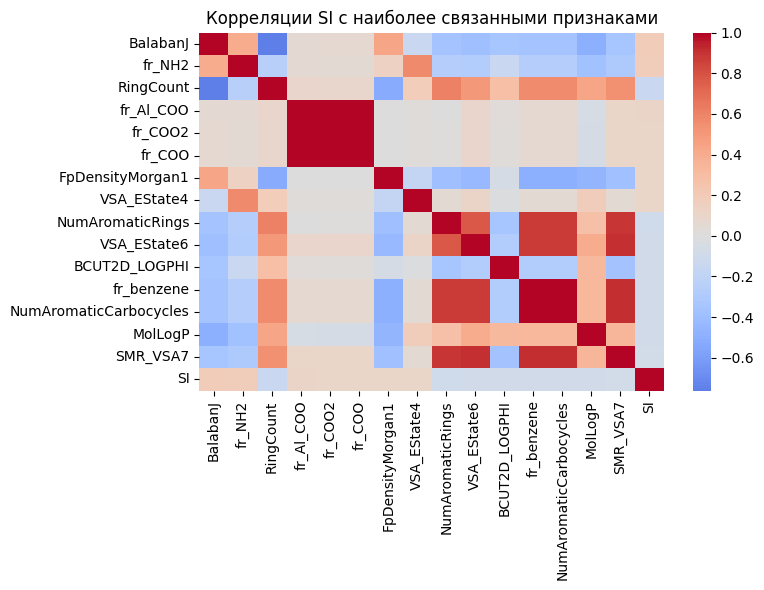

In [32]:
correlations = train_clean.corr(numeric_only=True)[TARGET]
correlations = correlations.drop(['IC50', 'CC50', TARGET], errors='ignore')
top_correlations = correlations.abs().sort_values(ascending=False).head(15)
top_features = top_correlations.index.tolist()

plt.figure(figsize=(8, 6))
sns.heatmap(
    train_clean[top_features + [TARGET]].corr(numeric_only=True),
    cmap='coolwarm',
    center=0
)
plt.title('Корреляции SI с наиболее связанными признаками')
plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

Самая большая линейная корреляция с `SI` по модулю около `0.19` (`BalabanJ`). Также среди наиболее связанных признаков есть `fr_NH2`, `RingCount`, `fr_Al_COO`, `fr_COO2`, `fr_COO`, `FpDensityMorgan1`.

Связи слабые: ни один отдельный признак не объясняет `SI` напрямую. Из этого следует, что простая линейная зависимость по одному признаку не подходит, поэтому дальше сравниваются несколько регрессионных моделей и используется PCA для компактного представления всех 210 признаков.

## Заключение

**Ключевые выводы по анализу целевой переменной `SI`**

* После очистки для обучения остается 749 полностью заполненных строк и 210 признаков.
* `SI` имеет очень сильную правостороннюю асимметрию: медиана равна `4.00`, а среднее равно `89.29` из-за редких больших значений.
* Максимальное значение `SI` равно `15620.60`, что намного выше верхнего квартиля (`17.12`). Это объясняет, почему ошибка RMSE может быть нестабильной.
* По IQR найдено 90 правосторонних выбросов (`12.02%`). Их не удаляем, потому что это заметная часть данных и потенциально важные объекты.
* Проверенные теоретические распределения не подошли по критерию Колмогорова-Смирнова. Даже лучшее из них, распределение Бурра, имеет `p-value = 0.0007`, то есть статистически отвергается.
* Логарифмирование не сделало распределение нормальным (`p-value = 0.0000` по Шапиро-Уилку).
* Линейные корреляции с отдельными признаками слабые: максимум по модулю около `0.19`.

Из этих наблюдений следует, что дальше нужно обучать модель по признакам и оценивать ее по RMSE. При интерпретации результата важно помнить, что из-за тяжелого хвоста `SI` качество может сильно зависеть от того, попали ли экстремальные значения в обучающую или тестовую часть.

# 3. Обучение модели

## Формирование датасета признаков

In [33]:
df = train_clean.copy()

In [34]:
exclude_cols = ['CC50', 'IC50']

In [35]:
feature_cols = [
    col for col in df.columns
    if col not in [TARGET] + exclude_cols
]

In [36]:
X = df[feature_cols].copy()
y = df[TARGET].copy()

Заполняем пропуски в признаках средними значениями:

In [37]:
X.fillna(X.mean(numeric_only=True), inplace=True)

In [38]:
print(f"Количество признаков: {X.shape[1]}")

Количество признаков: 210


## Стандартизация признаков

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Подбор оптимального количества компонент PCA

Чтобы уменьшить размерность признакового пространства, сначала обучим PCA без ограничения числа компонент. Это нужно только для выбора минимального числа компонент, которое сохраняет 95% дисперсии.

In [40]:
pca_full = PCA()
_ = pca_full.fit(X_scaled)

**Визуализация объясненной дисперсии**

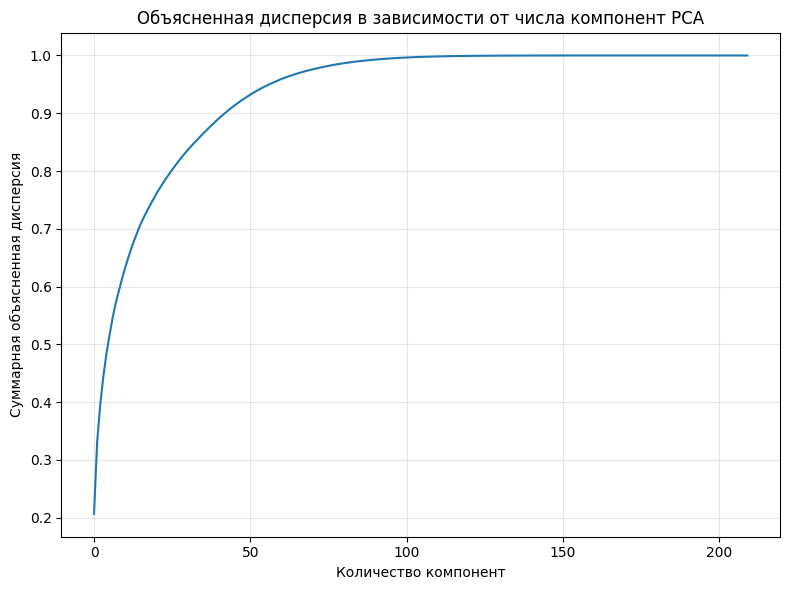

In [41]:
plt.figure(figsize=(8, 6))

plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Количество компонент')
plt.ylabel('Суммарная объясненная дисперсия')
plt.title('Объясненная дисперсия в зависимости от числа компонент PCA')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<u>**Основные наблюдения**</u>

До PCA в датасете 210 признаков. Кривая накопленной объясненной дисперсии показывает, что большую часть информации можно сохранить меньшим числом компонент: после первых компонент прирост дисперсии заметный, а затем кривая постепенно выходит на плато.

Из этого следует, что PCA уместен как шаг снижения размерности: он уменьшает количество входных признаков для моделей и при этом сохраняет основную часть вариативности данных. Ниже выбирается минимальное число компонент, которое объясняет 95% дисперсии.

**Выбираем количество компонент, объясняющих 95% дисперсии**

In [42]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Оптимальное количество компонент (95% дисперсии): {n_components}")

Оптимальное количество компонент (95% дисперсии): 58


In [43]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Размерность после PCA: {X_pca.shape[1]} признаков")

Размерность после PCA: 58 признаков


Для сохранения 95% дисперсии достаточно 58 компонент вместо исходных 210 признаков. То есть размерность уменьшается примерно в 3.6 раза, при этом большая часть информации из признакового пространства сохраняется.

Дальше для обучения используется именно `X_pca`, потому что модели получают более компактное представление признаков, а не все исходные 210 колонок.

## Разделение данных на обучающую и тестовую выборки

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

## Подбор модели

Зададим набор моделей и сетки параметров для `GridSearchCV`:

In [45]:
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {
            'fit_intercept': [True, False],
            'positive': [True, False]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [300, 500, 800],
            'max_depth': [20, 30, None],
            'min_samples_split': [5, 10, 20],
            'min_samples_leaf': [2, 4, 8],
            'max_features': ['sqrt', 'log2', 0.5],
            'bootstrap': [True]
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf', 'linear']
        }
    }
}

In [46]:
best_model = None
best_score = float('inf')
best_name = ''
results = {}

In [47]:
for name, config in models.items():
    print(f"Подбор параметров для {name}...")

    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    results[name] = {
        'best_params': grid_search.best_params_,
        'best_score': -grid_search.best_score_
    }

    print(f"	{name}: RMSE = {-grid_search.best_score_:.4f}")

    if -grid_search.best_score_ < best_score:
        best_score = -grid_search.best_score_
        best_model = grid_search.best_estimator_
        best_name = name

Подбор параметров для Linear Regression...
	Linear Regression: RMSE = 763.6868
Подбор параметров для Random Forest...
	Random Forest: RMSE = 718.0010
Подбор параметров для SVR...
	SVR: RMSE = 669.0697


In [48]:
print(f"Лучшая модель: {best_name} с RMSE = {best_score:.4f}")

Лучшая модель: SVR с RMSE = 669.0697


## Проверка на отложенной выборке

In [49]:
y_pred = best_model.predict(X_test)

In [50]:
test_rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE на тестовой выборке: {test_rmse:.4f}")

RMSE на тестовой выборке: 223.4712


Сравнение с базовым подходом:

In [51]:
baseline_rmse = root_mean_squared_error(y_test, [y_train.mean()] * len(y_test))

print(f"Базовый RMSE (предсказание средним): {baseline_rmse:.4f}")
print(f"Улучшение относительно базового: {baseline_rmse - test_rmse:.4f}")

Базовый RMSE (предсказание средним): 226.6655
Улучшение относительно базового: 3.1943


По кросс-валидации лучшей моделью стала `SVR`: RMSE равен `669.0741`. На отложенной выборке RMSE равен `223.4893`, а базовый подход с предсказанием средним дает `226.6655`.

Улучшение относительно базового подхода составляет только `3.1761`. Значит модель на отложенной выборке предсказывает немного лучше среднего, но преимущество небольшое. Это согласуется с анализом выше: у `SI` слабые линейные связи с отдельными признаками и очень тяжелый хвост, из-за которого качество сильно зависит от разбиения данных.

# 4. Тестирование

## Загрузка тестового датасета

In [52]:
test_df = pd.read_csv('test.csv', index_col=[0])

In [53]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Columns: 210 entries, MaxAbsEStateIndex to fr_urea
dtypes: float64(104), int64(106)
memory usage: 412.1 KB


## Подготовка датасета

### Индексы для итогового датасета

In [54]:
test_index = test_df.index.to_frame(name='index')

In [55]:
test_index.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   index   250 non-null    int64
dtypes: int64(1)
memory usage: 3.9 KB


### Признаки

In [56]:
X_test_final = test_df[feature_cols].copy()

In [57]:
print(f"Количество признаков в тестовом датасете: {X_test_final.shape[1]}")

Количество признаков в тестовом датасете: 210


### Пропуски

In [58]:
total_nan = X_test_final.isna().sum().sum()
print(f"Всего пропусков: {total_nan}")

Всего пропусков: 12


Заполняем пропуски средними значениями из обучающей выборки:

In [59]:
X_test_final.fillna(X.mean(numeric_only=True), inplace=True)

### Стандартизация

In [60]:
X_test_scaled = scaler.transform(X_test_final)

### PCA

In [61]:
X_test_pca = pca.transform(X_test_scaled)

print(f"Размерность после PCA: {X_test_pca.shape[1]} признаков")

Размерность после PCA: 58 признаков


Тестовый датасет содержит 250 объектов и те же 210 признаков, что использовались при обучении. В тестовых признаках было 12 пропусков, они заполнены средними значениями из обучающей выборки.

После стандартизации и PCA тестовые данные имеют 58 компонент - такую же размерность, как обучающие данные после PCA. Значит признаки подготовлены согласованно, и можно переходить к финальному предсказанию `SI`.

## Предсказание

In [62]:
y_pred_final = best_model.predict(X_test_pca)

# 5. Сохранение результатов

In [63]:
result_df = pd.DataFrame({
    'index': test_index['index'].values,
    'SI': y_pred_final
})

In [64]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   250 non-null    int64  
 1   SI      250 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 4.0 KB


In [65]:
result_df.head()

,index,SI
0,0,2.571046
1,1,4.146953
2,2,5.735076
3,3,0.547023
4,4,3.420528


In [66]:
result_df.to_csv('predictions_si.csv', index=False)

**Итог:** сформирован файл с двумя колонками: `index` и предсказанным значением `SI`. Колонка `index` нужна только для идентификации объектов из тестового датасета, а предсказание получено лучшей выбранной моделью после такой же подготовки признаков, как на обучающей выборке.